In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from experiment_utils import run_one_experiment, run, save_result_v1, MLPClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
FEATURE_COLS = [
    "rank_advantage",
    "elo_advantage",
    "form_diff_ema50"
]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")

data = data.drop(columns=["Unnamed: 0"], errors="ignore")

data["date"] = pd.to_datetime(data["date"], format="mixed")
data = data.sort_values("date").reset_index(drop=True)

data = data.dropna(subset=FEATURE_COLS + ["result"]).reset_index(drop=True)

X = data[FEATURE_COLS].values.astype(np.float32)

# -1, 0, 1 -> 0, 1, 2
y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))
print("Input dim:", X_train_tensor.shape[1])

Train size: 888 Test size: 222
Input dim: 3


In [3]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8655 | val loss = 0.7120 | val acc = 0.6854
Epoch 100/1000 | train loss = 0.8605 | val loss = 0.7193 | val acc = 0.6742
Epoch 150/1000 | train loss = 0.8423 | val loss = 0.7162 | val acc = 0.6854
Epoch 200/1000 | train loss = 0.8512 | val loss = 0.7205 | val acc = 0.6854
Epoch 250/1000 | train loss = 0.8449 | val loss = 0.7229 | val acc = 0.6573
Epoch 300/1000 | train loss = 0.8384 | val loss = 0.7285 | val acc = 0.6629
Epoch 350/1000 | train loss = 0.8323 | val loss = 0.7254 | val acc = 0.6685
Epoch 400/1000 | train loss = 0.8184 | val loss = 0.7306 | val acc = 0.6517
Epoch 450/1000 | train loss = 0.8141 | val loss = 0.7365 | val acc = 0.6292
Epoch 500/1000 | train loss = 0.8080 | val loss = 0.7354 | val acc = 0.6517
Epoch 550/1000 | train loss = 0.8072 | val loss = 0.7414 | val acc = 0.6517
Epoch 600/1000 | train loss = 0.8096 | val loss = 0.7442 | val acc = 0.6404
Epoch 650/1000 | train loss = 0.8002 | val loss = 0.7420 | val acc = 0.6292
Epoch 700/100

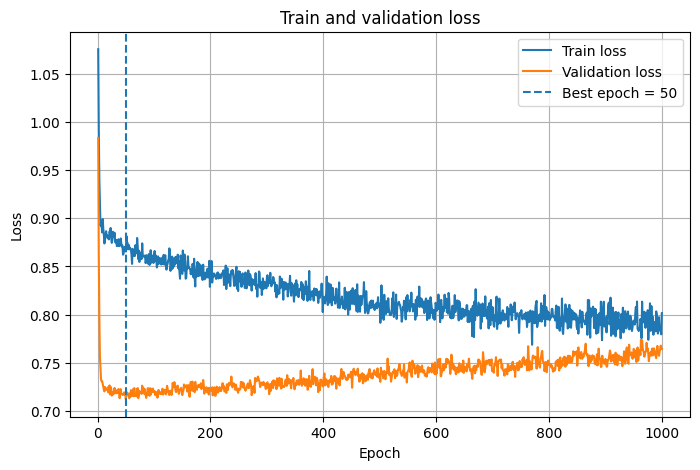

0.6396396396396397

In [4]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [5]:
best_num_epochs = 50

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6396 | Precision: 0.4198 | Recall: 0.5310 | Specificity: 0.7901 | F1: 0.4688

Run 2/10
Accuracy: 0.6441 | Precision: 0.5374 | Recall: 0.5402 | Specificity: 0.7943 | F1: 0.4871

Run 3/10
Accuracy: 0.6622 | Precision: 0.7669 | Recall: 0.5585 | Specificity: 0.8032 | F1: 0.5099

Run 4/10
Accuracy: 0.6351 | Precision: 0.4896 | Recall: 0.5278 | Specificity: 0.7897 | F1: 0.4794

Run 5/10
Accuracy: 0.6532 | Precision: 0.4286 | Recall: 0.5443 | Specificity: 0.7990 | F1: 0.4796

Run 6/10
Accuracy: 0.6486 | Precision: 0.5937 | Recall: 0.5432 | Specificity: 0.7962 | F1: 0.4890

Run 7/10
Accuracy: 0.6532 | Precision: 0.5970 | Recall: 0.5484 | Specificity: 0.7992 | F1: 0.4931

Run 8/10
Accuracy: 0.6532 | Precision: 0.4286 | Recall: 0.5443 | Specificity: 0.7990 | F1: 0.4796

Run 9/10
Accuracy: 0.6441 | Precision: 0.4254 | Recall: 0.5382 | Specificity: 0.7941 | F1: 0.4752

Run 10/10
Accuracy: 0.6441 | Precision: 0.5922 | Recall: 0.5443 | Specificity: 0.7943 | F1: 0.4982

Summary o

In [7]:
save_result_v1(
    experiment_name="Experiment_3-5_ranks_diff_EMA_diff",
    summary=summary
)


Saved result for Experiment_3-5_ranks_diff_EMA_diff
File: ../results/experiment_summary_v1.csv
